## Random Forest Model

In [8]:
import numpy as np
import pandas as pd
import joblib
from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [9]:
# Load data
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
test_ids = test_df["id"].copy()

# Drop id
train_df = train_df.drop(columns=["id"])
test_df = test_df.drop(columns=["id"])

# Binary encode internet_access
train_df["internet_access"] = train_df["internet_access"].map({"yes": 1, "no": 0})
test_df["internet_access"] = test_df["internet_access"].map({"yes": 1, "no": 0})

# One-hot encode categorical features
categorical_features = [
    "gender", "course", "sleep_quality",
    "study_method", "facility_rating", "exam_difficulty",
]
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded_train = encoder.fit_transform(train_df[categorical_features])
encoded_test = encoder.transform(test_df[categorical_features])
encoded_names = encoder.get_feature_names_out(categorical_features)

train_df = pd.concat(
    [train_df.drop(columns=categorical_features),
     pd.DataFrame(encoded_train, columns=encoded_names)],
    axis=1,
)
test_df = pd.concat(
    [test_df.drop(columns=categorical_features),
     pd.DataFrame(encoded_test, columns=encoded_names)],
    axis=1,
)

target = "exam_score"
y = train_df[target]
X = train_df.drop(columns=[target])
X_submission = test_df[X.columns]

# Split training data into train/validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Train Random Forest

In [10]:
rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [11]:
pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_,
}).sort_values("Importance", ascending=False).head(15)

,Feature,Importance
1,study_hours,0.643982
2,class_attendance,0.138558
4,sleep_hours,0.051738
14,sleep_quality_poor,0.025009
0,age,0.022335
19,facility_rating_low,0.019742
13,sleep_quality_good,0.014790
18,study_method_self-study,0.010340
17,study_method_online videos,0.009068
15,study_method_group study,0.008371


### Evaluate

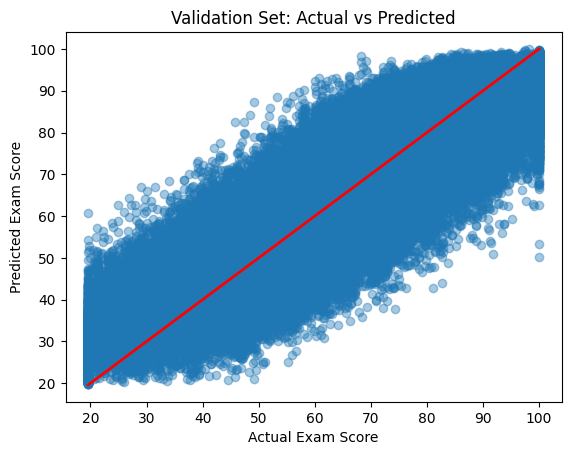

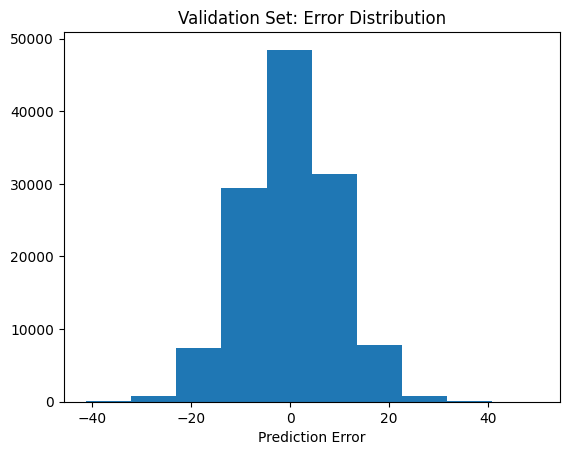

Metrics saved to ../metrics/random_forest_metrics.csv


,MAE,MSE,RMSE,R2
0,7.249723,82.954104,9.107914,0.766752


In [12]:
y_val_pred = rf.predict(X_val)

# Actual vs Predicted
plt.scatter(y_val, y_val_pred, alpha=0.4)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r", lw=2)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Validation Set: Actual vs Predicted")
plt.show()

# Error distribution
plt.hist(y_val - y_val_pred)
plt.xlabel("Prediction Error")
plt.title("Validation Set: Error Distribution")
plt.show()

# Metrics
pd.set_option("float_format", "{:f}".format)
res_metrics = pd.DataFrame({
    "MAE": [metrics.mean_absolute_error(y_val, y_val_pred)],
    "MSE": [metrics.mean_squared_error(y_val, y_val_pred)],
    "RMSE": [np.sqrt(metrics.mean_squared_error(y_val, y_val_pred))],
    "R2": [metrics.r2_score(y_val, y_val_pred)],
})
res_metrics.to_csv("../metrics/random_forest_metrics.csv", index=False)
print("Metrics saved to ../metrics/random_forest_metrics.csv")
res_metrics

### Generate Submission

In [13]:
y_submission_pred = rf.predict(X_submission)
submission = pd.DataFrame({"id": test_ids, "exam_score": y_submission_pred})
submission.to_csv("../submission/random_forest_submission.csv", index=False)
print("Submission saved to ../submission/random_forest_submission.csv")
submission

Submission saved to ../submission/random_forest_submission.csv


,id,exam_score
0,630000,69.334587
1,630001,69.605926
2,630002,85.583696
3,630003,53.349361
4,630004,48.703553
...,...,...
269995,899995,63.855583
269996,899996,38.356501
269997,899997,86.076372
269998,899998,51.643747


In [14]:
# Save model
joblib.dump(rf, "../models/random_forest.pkl")
print("Model saved to ../models/random_forest.pkl")

Model saved to ../models/random_forest.pkl
